In [1]:
%pip install dash dash-bootstrap-components

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import dash
import dash_bootstrap_components as dbc
from dash import dcc, html, Input, Output
import plotly.express as px

# Load dataset
df = pd.read_csv("cleaned_sleep_data.csv")

# Create Age Groups
df["Age Group"] = pd.cut(df["Age"], bins=[0, 20, 30, 40, 50, 60, 100],
                         labels=["<20", "21–30", "31–40", "41–50", "51–60", "60+"])

# Initialize Dash App
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.CYBORG])
app.title = "Sleep Health & Productivity Dashboard"

# Layout
app.layout = dbc.Container([
    dbc.Row([
        dbc.Col(html.H2("Sleep Health & Productivity Insights", className="text-center text-info mb-4"), width=12)
    ]),

    dbc.Row([
        dbc.Col([
            html.Label("Select Sleep Category"),
            dcc.Dropdown(
                options=[{"label": cat, "value": cat} for cat in df["Sleep Category"].dropna().unique()],
                value="Optimal",
                id="sleep-category"
            )
        ], md=4),
        dbc.Col([
            html.Label("Select Stress Category"),
            dcc.Dropdown(
                options=[{"label": cat, "value": cat} for cat in df["Stress Category"].dropna().unique()],
                value="Medium",
                id="stress-category"
            )
        ], md=4),
    ], className="mb-4"),

    dbc.Row([
        dbc.Col(dcc.Graph(id="sleep-productivity-scatter"), md=6),
        dbc.Col(dcc.Graph(id="mood-boxplot"), md=6),
    ]),

    dbc.Row([
        dbc.Col(dcc.Graph(id="heatmap-correlation"), md=6),
        dbc.Col(dcc.Graph(id="sleepquality-histogram"), md=6),
    ]),

    dbc.Row([
        dbc.Col(dcc.Graph(id="mood-line"), md=6),
        dbc.Col(dcc.Graph(id="productivity-age-bar"), md=6),
    ])
], fluid=True)


# Callbacks
@app.callback(
    Output("sleep-productivity-scatter", "figure"),
    Output("mood-boxplot", "figure"),
    Output("heatmap-correlation", "figure"),
    Output("sleepquality-histogram", "figure"),
    Output("mood-line", "figure"),
    Output("productivity-age-bar", "figure"),
    Input("sleep-category", "value"),
    Input("stress-category", "value")
)
def update_graphs(selected_sleep, selected_stress):
    filtered_df = df[(df["Sleep Category"] == selected_sleep) & (df["Stress Category"] == selected_stress)]

    scatter_fig = px.scatter(
        filtered_df,
        x="Total Sleep Hours",
        y="Productivity Score",
        color="Stress Level",
        title="Sleep Hours vs Productivity",
        labels={"Total Sleep Hours": "Sleep Hours", "Productivity Score": "Productivity"},
    )

    box_fig = px.box(
        filtered_df,
        x="Sleep Quality",
        y="Mood Score",
        title="Mood Score Across Sleep Quality",
        color="Sleep Quality"
    )

    corr = df[["Total Sleep Hours", "Sleep Quality", "Mood Score", "Stress Level", "Productivity Score"]].corr()
    heatmap_fig = px.imshow(
        corr,
        text_auto=True,
        aspect="auto",
        color_continuous_scale="RdBu_r",
        title="Correlation Heatmap"
    )

    hist_fig = px.histogram(
        df,
        x="Sleep Quality",
        nbins=10,
        title="Distribution of Sleep Quality",
        color_discrete_sequence=["#00BFFF"]
    )

    line_fig = px.line(
        df.groupby("Stress Level")["Mood Score"].mean().reset_index(),
        x="Stress Level",
        y="Mood Score",
        markers=True,
        title="Average Mood Score vs Stress Level"
    )

    bar_fig = px.bar(
        df.groupby("Age Group")["Productivity Score"].mean().reset_index(),
        x="Age Group",
        y="Productivity Score",
        title="Avg Productivity Score by Age Group",
        color="Age Group"
    )

    return scatter_fig, box_fig, heatmap_fig, hist_fig, line_fig, bar_fig



if __name__ == "__main__":
    app.run(host='0.0.0.0', port=8000, debug=True)

# http://0.0.0.0:8000/ after running the code, go to mentioned address


/var/folders/td/7y_4cq0535qfps8wc87qt7m80000gn/T/ipykernel_27171/3802118129.py:117: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/td/7y_4cq0535qfps8wc87qt7m80000gn/T/ipykernel_27171/3802118129.py:117: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



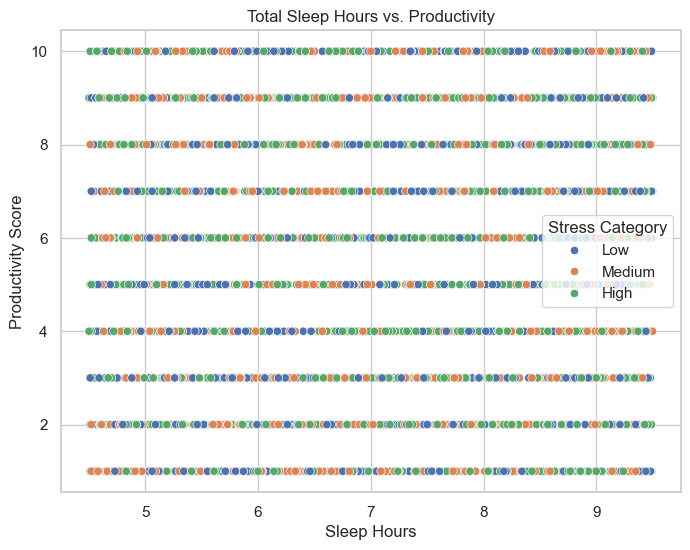

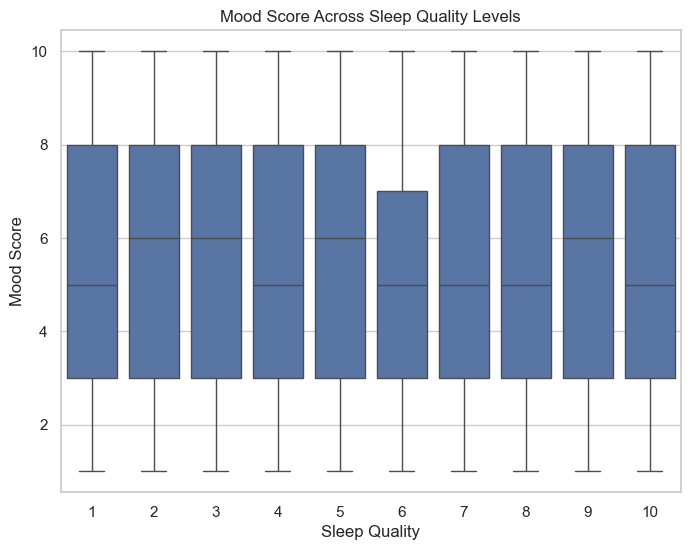

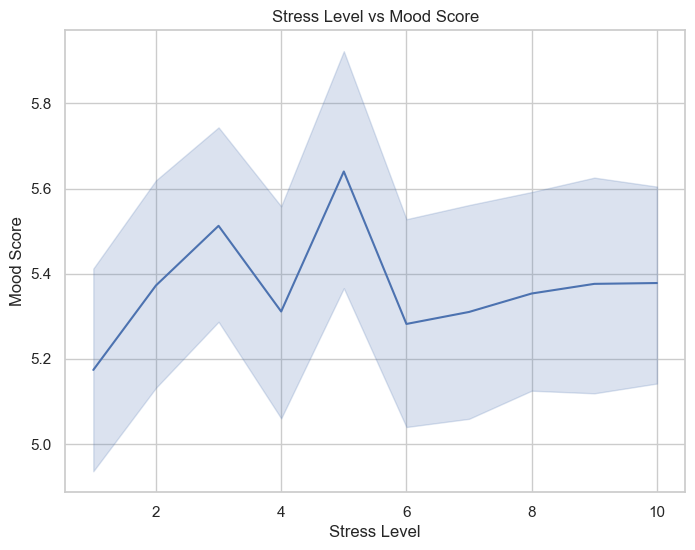

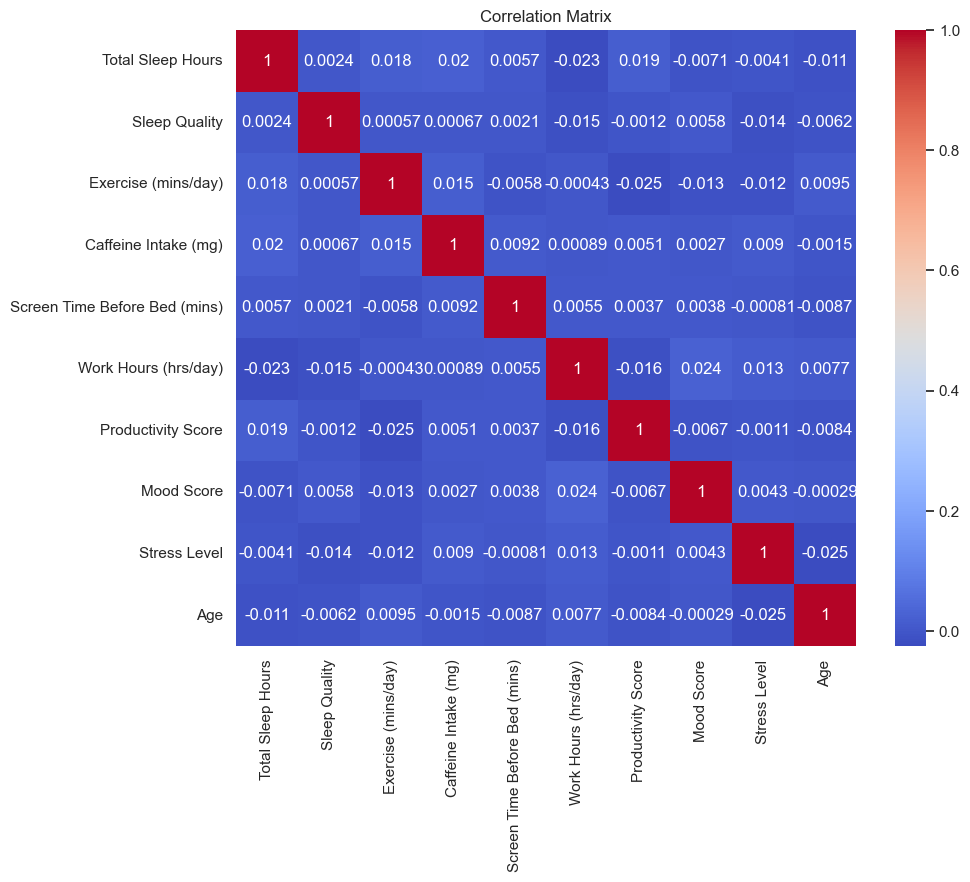

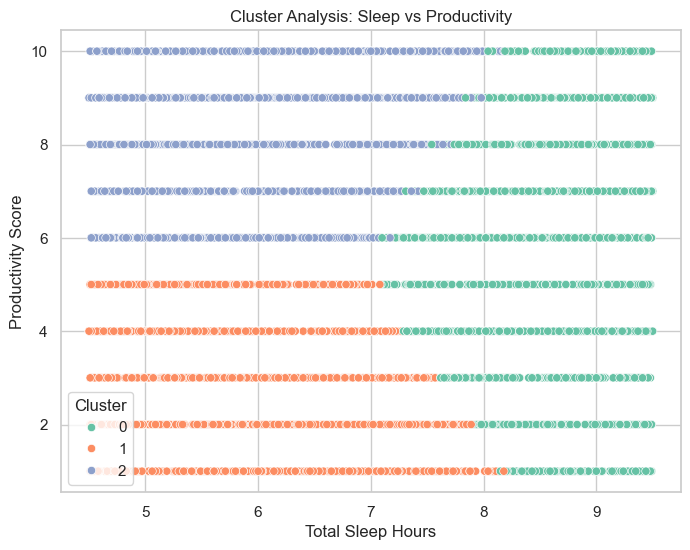

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load CSV file
df = pd.read_csv("sleep_cycle_productivity.csv")

# Feature engineering
df['Sleep Category'] = pd.cut(df['Total Sleep Hours'], bins=[0, 5, 7, 9, 12],
                              labels=['Low', 'Below Avg', 'Optimal', 'High'])
df['Stress Category'] = pd.cut(df['Stress Level'], bins=[0, 3, 6, 10],
                               labels=['Low', 'Medium', 'High'])
df['MoodProductivityGap'] = df['Mood Score'] - df['Productivity Score']

# Set plot style
sns.set(style='whitegrid')

# 1. Scatter Plot: Sleep vs Productivity
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Total Sleep Hours', y='Productivity Score', hue='Stress Category')
plt.title("Total Sleep Hours vs. Productivity")
plt.xlabel("Sleep Hours")
plt.ylabel("Productivity Score")
plt.show()

# 2. Boxplot: Sleep Quality vs Mood
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Sleep Quality', y='Mood Score')
plt.title("Mood Score Across Sleep Quality Levels")
plt.show()

# 3. Line Plot: Stress Level vs Mood
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x='Stress Level', y='Mood Score')
plt.title("Stress Level vs Mood Score")
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['Total Sleep Hours', 'Sleep Quality', 'Exercise (mins/day)',
                'Caffeine Intake (mg)', 'Screen Time Before Bed (mins)',
                'Work Hours (hrs/day)', 'Productivity Score', 'Mood Score',
                'Stress Level', 'Age']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 5. Cluster Analysis
features = df[['Total Sleep Hours', 'Sleep Quality', 'Stress Level', 'Mood Score', 'Productivity Score']]
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

# Cluster plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Total Sleep Hours', y='Productivity Score', hue='Cluster', palette='Set2')
plt.title("Cluster Analysis: Sleep vs Productivity")
plt.show()
